#MNIST Data

#Import Libraries

The code cell below contains all the python packages you will need to complete this assignment. Do not update the python package or add new ones. Doing so will may cause the autograder to fail.

In [ ]:
#Basic libraries for functionalities
import numpy as np              #numpy library stands for numerical python - they create a datatype called arrays which speeds up calculation
import matplotlib.pyplot as plt #matplotlib is a library used for drawing graphs and plotting
import cv2                      #cv2 library is for computer vision application - mostly used for working with images
import random                   #used to create random datasets
import pandas as pd             #used to read data

# Machine learning elements downloaded over here
from sklearn.metrics import confusion_matrix #sklearn stands for scinetific kit learn - It contains a bunch of ML functions and useful functions to work with
from sklearn import svm                      #svm is the support vector machine - our model that we want to implement
from sklearn.model_selection import train_test_split, GridSearchCV # train test split is used to split our data into training and testing set and grid search will be used for hyperparameter optimization later on

# mock testing
from unittest.mock import Mock, patch, ANY



#Load Data

The first step is to load the data into a format that we can use.

The data has been downloaded and is in the same directory as this notebook. We can use numpy to read in the csv files into an numpy array.

The features and labels are in the files mnist_features.csv and mnist_labels.csv respectively

We will use the numpy method 'loadtxt' to import the label data into the variable 'labels'. The arguments we are using are:

labels_csv: file path = mnist_labels.csv
delimiter: comma since we are reading a csv
dtype: we want the datatype of the resulting array to be integer
skiprows: set to 0 since there is no header row
Run the code below to import the label data into a numpy array.

In [ ]:
# Load label data into a numpy array
labels_csv = '/content/sample_data/mnist_train_small.csv'
labels = np.loadtxt(labels_csv, delimiter=',', dtype=int, skiprows=0)

Run the cell below to print out information regarding the label data. Feel free to add additional print statements to help understand the data.

In [ ]:
'''
Print:
 - the shape of the labels array: One dimensional array with 70,000 elements (60,000 training and 10,000 testing)
 - the first element in the array: 5
 - the type of an array element: numpy.int64 : The data is stored as numpy array (helps in speeding up calculation), where int64 represents it is integer datatype occupying 64 bits of memory
'''

print(f"Labels shape: {labels.shape}")
print(f"Value of the first label: {labels[0]}")
print(f"Data type of the label element: {type(labels[0])}")

Labels shape: (20000, 785)
Value of the first label: [  6   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  24  67  67
  18   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0 131 252 252  66   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 159 250
 232  30  32   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0  15 222 252 108   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 14

We will now use the numpy method 'loadtxt' to import the feature data into the variable features. The arguments we are using are:

features_csv: file path = mnist_features.csv
delimiter: comma since we are reading a csv
dtype: we want the datatype of the resulting array to be float
skiprows: set to 0 since there is no header row
Run the code below to import the feature data into a numpy array.

In [ ]:
# Load feature data into a numpy array
# The mnist_train_small.csv file (loaded into 'labels' in the previous cell)
# contains both the actual labels (first column) and the features (remaining columns).
# We extract the features from the 'labels' array, converting them to float.
features = labels[:, 1:].astype(float)

Run the cell below to print out information regarding the feature data.  Feel free to add additional print statements to help understand the data.

In [ ]:
'''
Print:
 - the shape of the features array: Two dimension array (70000, 784) : The first element - 70,000 is the total number of images and the second element is the size of each image - which is 784 pixels
 - we print out what values are in the 784 pixesl of the first feature(image)
 - the datatype of the first array element: numpy.ndarray

 - the value of the first element in the first feature array: 0.0
 - the type of the first element in the first feature array: numpy.float64
'''

print(f"Features shape: {features.shape}")
print(f"Value of the first feature: {features[0]}")
print(f"Data type of the feature element: {type(features[0])}")
print()
print(f"Value of the first element in the first feature array: {features[0][0]}")
print(f"Data type of the first element in the first feature array: {type(features[0][0])}")

Features shape: (20000, 784)
Value of the first feature: [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  24.  67.  67.  18.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. 131. 252. 252.  66.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0. 159. 250. 232.  30.  32.
   0.   0.   0.   0.

#View Sample Image

After loading the data, it is useful to look at a sample image.
Run the commands below to see the data shape and the first image. It should see an image of the number 5, which we earlier learnt is the first image in the feature array.

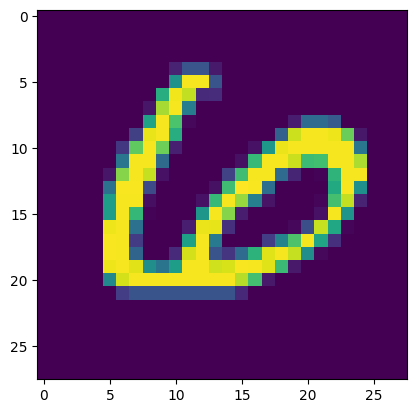

In [ ]:
'''
The code below will take the first element from the feature variable having a size of 784 pixels
and convert it to a 28 x 28 using reshape method two dimensional array for matplotlib to display.
'''

plt.imshow(features[0].reshape((28, 28)))

#Subsampling

There are currently 70,000 images in our data set. To make the model training time shorter, we need to reduce the number of samples.

Implement the method subsample below to reduce the number of samples to 10,000. Made sure all 10 label possibilities are equally represented (1000 images per label).

Your method must take in the feature set (2 dimensional numpy array which contains images and is of the size (70,000, 784)) and the label set (1 dimensional numpy array which contains the labels and is of the size (70,000)).

Do not change the method name, signature, or return values.

In [ ]:
def subsample(x, y):
    '''
    x: Feature set, as a 2 dimensional numpy array
    y: Labels, as a 1 dimensional numpy array

    Return: x_small, y_small subsampled MNIST dataset containing 1,000 images of each digit
    '''

    idx = []                                           # A blank array to hold the list of indices of subsampled. Fill in idx with a list of label indicies (1000 per label)
    for i in range(10):                             # A for loop that goes through all the different classes of data from 0 to 9
       idx.extend(np.where(y == i)[0][:1000])      # here we check for each class by np.where and extract the first 1000 values of their class
    random.shuffle(idx)                              # Shuffle the index array so that the data points are not in order
    x_small = x[idx]                                # Create the subsampled feature array
    y_small = y[idx]                                # create the subsampled label array
    return x_small, y_small                              # return the subsampled feature and the subsampled array

Subsample the data set by calling the subsample method.

Put the features in the variable features_subsampled and the labels in labels_subsampled

Print the shape of both your feature and label arrays to verify they are as expected.

In [ ]:
"""
Call your subsample method

Input:
 - features
 - labels
 - total number of subsamples

Output:
 - features_subsampled
 - lables_subsampled

Print:
 - shape of features_subsampled
 - shape of lables_subsampled
"""

# Call the subsample function with the parameters
features_subsampled, labels_subsampled = subsample(features, labels[:, 0])

# Print the shape of the subsampled feature and label arrays
print(f'Subsampled feature shape: {features_subsampled.shape}')
print(f'Subsampled labels shape:  {labels_subsampled.shape}')

Subsampled feature shape: (10000, 784)
Subsampled labels shape:  (10000,)


In [ ]:
###############################
##### TEST YOUR CODE HERE #####
###############################

# Check that the subsampled arrays are the correct size

features_subsampled_shape_expected = (10000, 784)
labels_subsampled_shape_expected = (10000,)

features_subsampled_shape_actual = features_subsampled.shape
labels_subsampled_shape_actual = labels_subsampled.shape

assert features_subsampled_shape_actual == features_subsampled_shape_expected, \
    f"Incorrect.  Feature shape after subsampling should be {features_subsampled_shape_expected}, your method returned {features_subsampled_shape_actual}."

assert labels_subsampled_shape_actual == labels_subsampled_shape_expected, \
    f"Incorrect.  Label shape after subsampling should be {labels_subsampled_shape_expected}, your method returned {labels_subsampled_shape_actual}."

print("Feature and Label shape after subsampling test passed.")


Feature and Label shape after subsampling test passed.


In [ ]:
###############################
##### TEST YOUR CODE HERE #####
###############################

# Check that the labels_subsampled array contains 1000 instances of each label value

for i in range(10):
    count = np.count_nonzero(labels_subsampled == i)
    assert count == 1000, f"The label {i} has {count} occurances instead of 1000"

print("Label count test passed")

Label count test passed


#Resizing Features

Fitting SVMs requires a decent amount of RAM. We will therefore downsample the original 28×28 images to 14×14.

Implement the method resize() where you will:

Convert the 784 element array to a 28x28 image
Downsample this 28x28 images to 14x14 using cv2.resize() method
Flatten the 14x14 image to a 196 element array

In [ ]:
def resize(x):
    '''
    The input argument is:
    x: numpy array of MNIST images
     - Note: x is a 2 dimensional array where the first dimension is the number of images and
             the second is the number of features per image.  In this case is it 784.

    return: the numpy array of resized (downsampled) MNIST data of shape (number of images, 196)
    '''

    num_img = x.shape[0]                                                           # Find the total number of datasets will be used later on
    x = x.reshape((num_img, 28, 28))                                             # convert the image to the size of 28*28 by using the resize function, quick tip - what will be the first parameter - think number of images? and how can that be adjusted?                                                          # find the total number of images by using the first parameter
    d_dsampled = np.zeros((num_img, 196))                                       # Create a downsampled array of size - num_images, 196 to store the downsampled image
    for i in range(num_img):                                                    # Go through all the images
        d_dsampled[i] = cv2.resize(x[i], (14, 14)).flatten()     # use the resize function on our dataset and convert it to the desired size - (14, 14) and then flatten it
    return d_dsampled                                                               # return the downsampled image

In [ ]:
###############################
##### TEST YOUR CODE HERE #####
###############################

# Test that cv2.resize() is called in resize

x = np.array([[i for i in range(784)]])

with patch("cv2.resize") as resize_mock:

    resize_mock.return_value = np.zeros((14, 14))

    try:
        resized_x = resize(x)
    except Exception as e:
        raise Exception("Failed to run resize()") from e

    try:
        resize_mock.assert_called_once()
    except AssertionError as e:
        raise AssertionError("Didn't use cv2.resize() to resize data.") from e

print('cv2.resize test passed')


cv2.resize test passed


Use the resize() method you wrote to resize the feature data. Put the result in the variable features_resized

In [ ]:
features_resized = resize(features_subsampled)                #call the function resize on the subsampled features dataset to get a subsampled data

print(f'Feature shape: {features_resized.shape}')         #check the resized data shape
print(f'Labels shape:  {labels_subsampled.shape}')         #check the resized label shape


Feature shape: (10000, 196)
Labels shape:  (10000,)


#Plot an image before and after resize

In the next two cells, pick one element and plot it before and after resizing. How different are the images? What trade offs are made when using a resized image?

Label for element 0 = 9


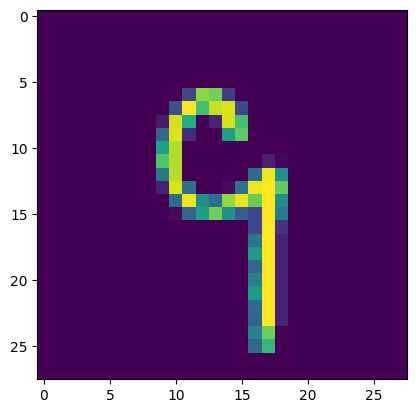

In [ ]:
# your code here
# we are going to see what an image looks like in the orignial form
i = 0                                                      # we choose the first element which is digit 5 for our example
print(f'Label for element {i} = {labels_subsampled[i]}')        # mention the labels_subsampled to fetch the labels
plt.imshow(features_subsampled[i].reshape(28, 28))           # call the original features dataset to show the image

### Plotting the Post-Resized Image

Now, let's visualize the same image after it has been resized to 14x14 pixels.

Label for element 0 = 9 (resized)


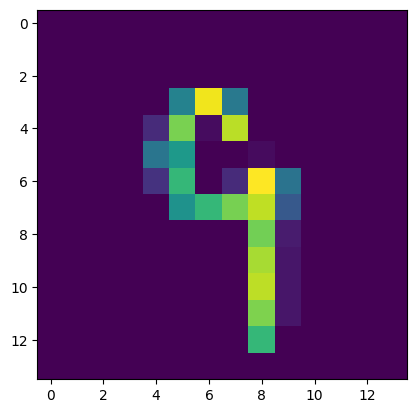

In [ ]:
# Plot the post-resized image
# We use the same index 'i' as before to plot the same digit
# Remember to reshape it to 14x14 as it was downsampled to 196 pixels

plt.imshow(features_resized[i].reshape(14, 14))
print(f'Label for element {i} = {labels_subsampled[i]} (resized)')

In [ ]:
# Check that the resized array is the correct size

features_resized_shape_expected = (10000, 196)

features_resized_shape_actual = features_resized.shape

assert features_resized_shape_actual == features_resized_shape_expected, \
    f"Incorrect.  Feature shape after resize should be {features_resized_shape_expected}, your method returned {features_resized_shape_actual}."

print("Feature shape after resize test passed.")


Feature shape after resize test passed.


Run cell below to initialize data for resize test

In [ ]:
np.save('feature_pre_resize.npy', features_subsampled)
np.save('feature_post_resize_expected.npy', features_resized)

feature_pre_resize = np.load('feature_pre_resize.npy')
feature_post_resize_expected = np.load('feature_post_resize_expected.npy')

In [ ]:
# Test resize method on specific testcase

feature_post_resized_actual = resize(feature_pre_resize)

assert np.allclose(feature_post_resized_actual, feature_post_resize_expected, 1e-4), \
    "post resize image is not correct"

print("Feature resize test passed.")


Feature resize test passed.


## Data Preprocessing

Construct the actual training dataset (80% of the data) and the testing dataset (20%) using `train_test_split()`.  This function returns training and testing sets that we will use to train the SVM. Note - we are going to use validation dataset and testing dataset interchangeably over here, however they are not the same. In any situation - around 80% of data is training data and 15% is testing data and 5% withheld data is the validation data - it is just use to check that the training is done well.

### Do not change the method name, signature, or return values.

In [ ]:
def data_preprocessing(x,y):
    '''
    x: Feature dataset after subsampling and resizing
    y: Feature dataset after subsampling

    return: x_train (feature training set),
            x_val (feature validation set),
            y_train (label training set),
            y_val (label validation set)

    Notes:Get train and validation split with random state 42, test size 0.2 (since we want 20% as validation set),
    shuffled, and stratified

    '''

    # your code here
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y) #this basically splits the whole datset into training and testing dataset for the purpose of keeping one part of data unseen for testing
                                                                                                                                                            # fill in teh blanks in the above line with the dataset you want to split, the proportion of the split (80-20), assign the random_state = 42 and the shuffle the data by assigning True and stratify the labels - y
    return x_train, x_val, y_train, y_val # return all the four datapoints


### Calling `data_preprocessing` and Verifying Split

Now, let's apply the `data_preprocessing` function to our `features_resized` and `labels_subsampled` data to obtain the training and validation sets.

In [ ]:
x_train, x_val, y_train, y_val = data_preprocessing(features_resized, labels_subsampled)

print(f'Shape of x_train: {x_train.shape}')
print(f'Shape of x_val: {x_val.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')

Shape of x_train: (8000, 196)
Shape of x_val: (2000, 196)
Shape of y_train: (8000,)
Shape of y_val: (2000,)


In [ ]:
# Test to verify that train_test_spllit was called correctly from data_preprocessing()

with patch("__main__.train_test_split") as train_test_split_mock:
    x, y = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    train_test_split_mock.return_value = x, y, x, y

    try:
        data_preprocessing(x, y)
    except Exception as e:
        raise Exception("Failed to run data_preprocessing()") from e

    try:
        # specify all parameters in their code otherwise assertion fails
        train_test_split_mock.assert_called_once_with(ANY, ANY, test_size=0.2, random_state=42, shuffle=True, stratify=ANY)
    except AssertionError as e:
        raise AssertionError("data_preprocessing() doesn't call train_test_split() with all parameters " + \
                             "defined correctly. train_test_split() should be called with test_size=0.2, " + \
                             "random_state=42, shuffled, and stratified") from e

print('data_preprocessing() call train_test_split() passed.')

data_preprocessing() call train_test_split() passed.


Call the data_preprocessing method

In [ ]:
'''
Call data_preprocessing.
Make sure the arguments are the features (after resizing and subsampling) and the labels (after subsampling) and not the original data set.
Put the return data in the variables: x_train, x_val, y_train, y_val

'''


x_train, x_val, y_train, y_val = data_preprocessing(features_resized, labels_subsampled) #Call the data preprocessing function with the resized features and subsampled labels

Print out the shape of each data set returned from data_preprocessing

In [ ]:
# Print out array shapes to verify each is the expected size

# your code here
print(f'Shape of x_train: {x_train.shape}')
print(f'Shape of x_val: {x_val.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')

Shape of x_train: (8000, 196)
Shape of x_val: (2000, 196)
Shape of y_train: (8000,)
Shape of y_val: (2000,)


In [ ]:
# Check that the training and validation arrays are the correct size

x_train_shape_expected = (8000, 196)
x_train_shape_actual = x_train.shape

assert x_train_shape_expected == x_train_shape_actual, \
    f"Incorrect.  x_train shape should be {x_train_shape_expected}, your method returned {x_train_shape_actual}."


x_val_shape_expected = (2000, 196)
x_val_shape_actual  = x_val.shape

assert x_val_shape_expected == x_val_shape_actual, \
    f"Incorrect.  x_val shape should be {x_val_shape_expected}, your method returned {x_val_shape_actual}."


y_train_shape_expected = (8000,)
y_train_shape_actual  = y_train.shape

assert y_train_shape_expected == y_train_shape_actual, \
    f"Incorrect.  y_train shape should be {y_train_shape_expected}, your method returned {y_train_shape_actual}."


y_val_shape_expected = (2000,)
y_val_shape_actual  = y_val.shape

assert y_val_shape_expected == y_val_shape_actual, \
    f"Incorrect.  y_val shape should be {y_val_shape_expected}, your method returned {y_val_shape_actual}."


print("x_train, y_train, x_val, y_val shape test passed.")


x_train, y_train, x_val, y_val shape test passed.


#Train an SVM

We are finally ready to train an SVM. Implement the method train_SVM() to train an SVM classifier on x_train, y_train. Then, later on we will test the trained SVM on x_val, y_val.

Create the SVM classifier in scikit-learn using:

classifier = svm.SVC(C=1.0, kernel=’rbf’, gamma=’auto’, cache_size=2000)

Where:

C: Regularization Parameter - this is used to control an issue called overfitting - a very common problem in learning models
kernel: Kernel type - It is the method we use to seperate the data
gamma: Kernel coefficient - This defines how much a single data point is influential in creating the seperation boundary
cache_size: Kernel cache - It is used to define the size of kernel cache which decides the speed of computation of Kernel matrix See the link before for more details:

The method should pass the regularization parameter, kernel, and gamma in as parameters.

In [ ]:
def train_SVM(x_train, y_train, C, kernel, gamma):
    '''
    Train SVM model using the fit method, given training data x_train and y_train

    Input:
    x_train: Feature training data
    y_train: Label training data

    C: regularization parameter
    kernel: kernel type
    gamma: kernel coefficient

    Return: The trained Classifier
    '''

# your code here
    clf = svm.SVC(C=C, kernel=kernel, gamma=gamma, cache_size=2000)  #initalize the SVM model over here with the
                                                                                                 # parameters of the SVM model - namely C, kernel and gamma and assign a suitable cache size for calculation and verbose value
    clf.fit(x_train, y_train) # fit trains the SVM classifier so assign it the trainig data
    return clf # return the classifier

In [ ]:
with patch("sklearn.svm.SVC") as svm_mock:
    x_train_mock, y_train_mock = np.array([1]), np.array([1])
    svm_mock.return_value = Mock()

    try:
        train_SVM(x_train_mock, y_train_mock, 1, 'rbf', 'auto')
    except Exception as e:
        raise Exception("Failed to run train_test_SVM()") from e

    try:
        svm_mock.assert_called_once()
    except AssertionError as e:
        raise Exception("SVC wasn't initialized in train_test_SVM(). Should initialize by calling svm.SVC() method.") from e

    try:
        svm_mock.return_value.fit.assert_called_once()
    except AssertionError as e:
        raise Exception("Didn't train the SVM in train_test_SVM(). fit() function should be called.") from e

print('train_SVM function passed.')

train_SVM function passed.


#Run SVM Trainer
Call your train_SVM() method with the training data. Use the following parameters: C = 1 kernel = 'rbf' gamma = 'auto'

In [ ]:
# Call train_SVM() using x_train and y_train
# For this run, use: C = 1, kernel = 'rbf', gamma = 'auto'

# your code here
clf = train_SVM(x_train, y_train, 1, 'rbf', 'auto') #Call the train SVM function with all the parameters to initalize and train your SVM classifier

#Support Samples

In [52]:
def get_number_of_support_samples(clf):
    '''
    clf: Model
    return: Total number of support samples
    '''

# your code here
    return np.sum(clf.n_support_)

#Evaluate the Model

In [54]:

'''
Print the classifier score and validation error, confusion matrix, and support sample ratio
Call get_number_of_support_samples() to calculate the total number of support samples
To calculate the support vector percentage - divide the total number of support samples by the total feature vector size
'''

# your code here
y_pred_val = clf.predict(x_val)                                                           # use the predict function on the testing data to get performance of trained model on testing data
print("Classifier Score: ", clf.score(x_val, y_val))                                    # score gives the accuray performance of the model - use it to get the performance of the model it works on testing data
print("Confusion Matrix: ")
print(confusion_matrix(y_val, y_pred_val))                                               # call the confusion matrix on the predicted data and the actual data
num_support_vectors = get_number_of_support_samples(clf)
print("Number Support Vectors: ", num_support_vectors)                  # Print number of support vectors of the classifier clf
total_training_samples = x_train.shape[0] # Interpreting 'Feature Vector Size' as total training samples for overfitting check
print("Feature Vector Size: ", total_training_samples)                                              # feature vectors used by our model
print("Support Vectors Percentage: ", num_support_vectors / total_training_samples)                         #get support vector percentage to check overfitting

Classifier Score:  0.214
Confusion Matrix: 
[[ 18   0   0   0   0   0   0   0   0 182]
 [  0   1   0   0   5   0   2   5   0 187]
 [  0   0   1   0   0   0   0   0   0 199]
 [  0   0   0  12   0   1   0   0   0 187]
 [  0   0   0   0  36   0   0   0   0 164]
 [  0   0   0   0   0  13   0   0   0 187]
 [  0   0   0   0   0   0  50   0   0 150]
 [  0   0   0   0   0   0   0  87   0 113]
 [  0   0   0   0   0   0   0   0  14 186]
 [  0   0   0   0   1   0   0   3   0 196]]
Number Support Vectors:  8000
Feature Vector Size:  8000
Support Vectors Percentage:  1.0


Improve Your Model by Optimizing Hyperparameters using grid_search_SVM()

In [56]:
def grid_search_SVM(x_train, y_train, params):
    '''
    x_train: feature training data
    y_train: label trainind data
    params: Dictionary of hyperparameters to test, where the parameter is the key and the value is a list of values to test.

    return: classifier
    '''

# your code here
    classifier = GridSearchCV(svm.SVC(cache_size=2000), params, cv=5, scoring='accuracy', verbose=10, n_jobs=-1) #Assign the cache size as done earlier, assign how many fold cross validation you want in cv and choose which metric to use for scoring and choose a suitable number of jobs for quick execution
    classifier.fit(x_train, y_train)                                                                                      #run the fit function on training data

    return classifier                                                                                                # return the trained classifier

Run grid_search_SVM()

In [58]:
'''
Call grid_search_SVM.

Define your parameter list.  Use a subset of the values below:

#params = {'C': [0.1, 10, 100, 1000, 10000], 'gamma': [1e-9, 1e-7, 1e-6, 1e-5, 1e-4, 5 * 1e-3, 1], 'kernel': ['rbf', 'poly']}

Put the results in the variable gs_svm

'''

# your code here
params = {'C': [0.1, 10], 'gamma': [1e-7, 1e-6],'kernel': ['rbf']}  #Choose only two values for C and gamma and just one value for kernel

gs_svm = grid_search_SVM(x_train, y_train, params) # Call the grid search function with all the datapoints and parameters

Fitting 5 folds for each of 4 candidates, totalling 20 fits


#Analyze the results

In [59]:
print('Best score for training data:', gs_svm.best_score_, "\n")
print('Best C:', gs_svm.best_estimator_.C, "\n")
print('Best Kernel:', gs_svm.best_estimator_.kernel, "\n")
print('Best Gamma:', gs_svm.best_estimator_.gamma, "\n")
print('Accuracy of hyperparameters tried:', gs_svm.cv_results_, '\n')

svm_best = gs_svm.best_estimator_
print('Best score for validation data:', svm_best.score(x_val, y_val))
y_pred_val = svm_best.predict(x_val)
print("Confusion Matrix: ")
print(confusion_matrix(y_pred_val, y_val))


Best score for training data: 0.9615 

Best C: 10 

Best Kernel: rbf 

Best Gamma: 1e-06 

Accuracy of hyperparameters tried: {'mean_fit_time': array([6.07611198, 2.74544382, 1.04265041, 1.18014421]), 'std_fit_time': array([0.12060985, 0.27743883, 0.04129286, 0.02900791]), 'mean_score_time': array([3.38950858, 2.69018526, 1.08459716, 1.21020131]), 'std_score_time': array([0.13096806, 0.26063093, 0.01665761, 0.38592234]), 'param_C': masked_array(data=[0.1, 0.1, 10.0, 10.0],
             mask=[False, False, False, False],
       fill_value=1e+20), 'param_gamma': masked_array(data=[1e-07, 1e-06, 1e-07, 1e-06],
             mask=[False, False, False, False],
       fill_value=1e+20), 'param_kernel': masked_array(data=['rbf', 'rbf', 'rbf', 'rbf'],
             mask=[False, False, False, False],
       fill_value=np.str_('?'),
            dtype=object), 'params': [{'C': 0.1, 'gamma': 1e-07, 'kernel': 'rbf'}, {'C': 0.1, 'gamma': 1e-06, 'kernel': 'rbf'}, {'C': 10, 'gamma': 1e-07, 'kernel': 'rb

Finally, run train_svm with the best C, kernel, and gamma values that you found and print the results.
Find values that will give a model accuracy > 0.95

In [61]:
# Fill in the C, kernel, and gamma values that provide the best accuracy.
# The accuracy must be greater than 0.95 to pass the autograder

# your code here
C = 10
kernel = 'rbf'
gamma = 1e-06                                     # Fill in a suitable value for C, kernel and gamma

clf_best = train_SVM(x_train, y_train, C, kernel, gamma) #Call the SVM function with all the right values


y_pred_val = clf_best.predict(x_val)                                                            # use the predict function on the testing data to get performance of trained model on testing data
print("Classifier Score: ", clf_best.score(x_val, y_val))                                     # score gives the accuray performance of the model - use it to get the performance of the model
print("Confusion Matrix: ")
print(confusion_matrix(y_val, y_pred_val))                                               # call the confusion matrix on the predicted data and the actual data
print("Number Support Vectors: ", get_number_of_support_samples(clf_best))                  # Print number of support vectors
print("Feature Vector Size: ", x_train.shape[0])                                             # feature vectors used by our model
print("Support Vectors Percentage: ", get_number_of_support_samples(clf_best) / x_train.shape[0])                        #get support vector percentage to check overfitting

Classifier Score:  0.962
Confusion Matrix: 
[[198   0   0   0   0   2   0   0   0   0]
 [  0 198   0   1   0   0   0   0   1   0]
 [  1   0 195   2   1   0   0   0   1   0]
 [  1   2   3 187   0   3   0   2   2   0]
 [  0   1   0   0 193   0   1   0   0   5]
 [  0   1   1   5   1 189   1   0   1   1]
 [  0   0   0   1   0   1 198   0   0   0]
 [  1   1   2   0   6   0   0 188   0   2]
 [  0   1   1   1   1   4   2   0 190   0]
 [  1   0   0   2   3   1   0   4   1 188]]
Number Support Vectors:  2728
Feature Vector Size:  8000
Support Vectors Percentage:  0.341


Compare the results

In [64]:
###############################
##### TEST YOUR CODE HERE #####
###############################

# Test the accuracy of the final model

# Combine x_val and y_val to create the validation data CSV
validation_data_to_save = pd.DataFrame(np.hstack((x_val, y_val.reshape(-1, 1))))
validation_data_to_save.to_csv('svm_validation_data.csv', header=False, index=False)

validation_data = pd.read_csv('svm_validation_data.csv', header=None)
# print(validation_data)
x_val_test = validation_data.iloc[:,:-1].to_numpy()
y_val_test = validation_data.iloc[:,-1].to_numpy()

accuracy = clf_best.score(x_val_test, y_val_test)
print(f'Accuracy: {accuracy}')
assert accuracy > 0.95
print('Your final model passed the accuracy test.')

Accuracy: 0.962
Your final model passed the accuracy test.


#Demonstration

You can use the code below to see that how your trained classifier performs when a random testing sample is used.

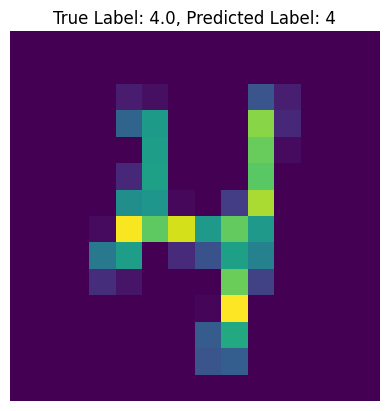

In [65]:
random_index = np.random.randint(0, x_val_test.shape[0])


sample_image = x_val_test[random_index]
true_label = y_val_test[random_index]

predicted_label = clf_best.predict([sample_image])[0]

plt.imshow(sample_image.reshape(14, 14))
plt.title(f"True Label: {true_label}, Predicted Label: {predicted_label}")
plt.axis('off')
plt.show()